# 08 — Long-Time Optimal Control and the Turnpike Property

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *What do optimal controls look like over long time horizons, and why do they stay close to the optimal steady state?*

Optimal design problems are often solved in a steady setting. Is this model reduction justified? To what extent, and in which regimes, is a time-evolution control problem approximated by its steady version? Symbolically:
$$
T\to\infty\ +\ \text{control}\quad\overset{?}{=}\quad\text{control}\ +\ T\to\infty .
$$
The answer depends heavily on **the controllability properties** and on **the criterion used to define optimal controls**. We start from a concrete example and let the computation show the phenomenon before explaining it.

### Table of Contents

1. **A concrete example** — the oscillator with a tracking cost
2. **The turnpike: three regions** — initial layer, plateau, terminal layer
3. **The steady problem** — the plateau computed by hand
4. **The optimality system** — forward state, backward adjoint
5. **Forward–backward structure and hyperbolicity** — the Hamiltonian matrix
6. **The turnpike theorem** — exponential closeness to the steady optimum
7. **The proof: dissipativity and the five steps** *(optional)*
8. **PDEs: balanced controls for the heat equation**
9. **Nonlinear turnpike and open problems** *(optional)*
10. **Control ↔ ML: long horizons and deep networks**
11. **Common misconceptions**
12. **Key takeaways**
13. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

In [2]:
# The three objects of this notebook, implemented under the formulas of §§3-5
def hamiltonian_matrix(A, B, C):
    """H = [[A, -BB^T], [-C^TC, -A^T]]: the matrix of the deviations (xi, eta)."""
    return np.block([[A, -B @ B.T], [-C.T @ C, -A.T]])

def lq_steady_state(A, B, C, x_star):
    """Steady optimum: A x + B u = 0, u = -B^T p, A^T p + C^T C (x - x*) = 0."""
    n = A.shape[0]
    M = np.block([[A, -B @ B.T], [C.T @ C, A.T]])
    # lstsq: the KKT system can be singular but consistent (e.g. a neutral unreachable mode)
    sol = np.linalg.lstsq(M, np.concatenate([np.zeros(n), C.T @ C @ x_star]), rcond=None)[0]
    x_bar, p_bar = sol[:n], sol[n:]
    return x_bar, -B.T @ p_bar, p_bar

def lq_optimality_system(A, B, C, x_star, x0, T, t):
    """Solve the optimality system on [0, T] by the stable/unstable splitting of H (§5).

    Only decaying exponentials are evaluated, so the e^{gamma T} growth of naive
    shooting never appears. Returns the optimal (x, p, u) on the grid t.
    """
    n = A.shape[0]
    x_bar, u_bar, p_bar = lq_steady_state(A, B, C, x_star)
    w, V = np.linalg.eig(hamiltonian_matrix(A, B, C))
    if np.min(np.abs(w.real)) < 1e-9:
        raise ValueError("the Hamiltonian matrix is not hyperbolic "
                         "(an eigenvalue lies on the imaginary axis)")
    s = w.real < 0
    Vs, ws, Vu, wu = V[:, s], w[s], V[:, ~s], w[~s]
    # boundary conditions: xi(0) = x0 - x_bar (top), eta(T) = -p_bar (bottom)
    M = np.block([[Vs[:n], Vu[:n] * np.exp(-wu * T)],
                  [Vs[n:] * np.exp(ws * T), Vu[n:]]])
    ab = np.linalg.solve(M, np.concatenate([x0 - x_bar, -p_bar]))
    a, b = ab[:n], ab[n:]
    z = ((a * np.exp(np.outer(t, ws))) @ Vs.T + (b * np.exp(np.outer(t - T, wu))) @ Vu.T).real
    x, p = x_bar + z[:, :n], p_bar + z[:, n:]
    return x, p, -p @ B

## Where are we?

> **Recap.** The minimal-norm control of the heat equation minimizes a cost on the control alone, under a terminal constraint. Its adjoint appears isolated in the optimality system and solves a backward heat equation, and for longer horizons the control acts mostly near $t=T$ ([notebook 07](07_adjoints_density_heat_control.ipynb)). Here the functional changes: a cost on the state couples state and adjoint in both directions. The optimality system of a problem with a state equation is derived with a Lagrangian, and the adjoint is the multiplier of the state equation.

## 1. A concrete example

The example is the harmonic oscillator $x_1''+x_1=u$ with a running cost:
$$
x_1'=x_2,\qquad x_2'=-x_1+u,\qquad x_1(0)=x_2(0)=0,
$$
$$
\min_u\ J_T(u)=\frac12\int_0^T\Big((x_1(t)-2)^2+(x_2(t)-7)^2+u(t)^2\Big)\,dt .
$$
The cost asks the state to stay close to $x^*=(2,7)$, with a moderate control, *during the whole interval* $[0,T]$. There is no terminal constraint. This is an LQ problem of the general form
$$
x'=Ax+Bu,\quad x(0)=x^0,\qquad J_T(u)=\frac12\int_0^T\big(|u|^2+|C(x-x^*)|^2\big)\,dt,
$$
here with $A=\begin{pmatrix}0&1\\-1&0\end{pmatrix}$, $B=\begin{pmatrix}0\\1\end{pmatrix}$ and $C=I$. Throughout, $(x,u,p)$ denotes the optimal state, control and adjoint state for the horizon $T$. They depend on $T$, which we do not write. The steady optimum of §3 is written $(\bar x,\bar u,\bar p)$. The problem has a unique optimal control: $J_T$ is continuous, strictly convex and coercive on $L^2(0,T)$, so the direct method applies.

**Code and plot.** Solve the problem for $T=2,5,10,20,40$. For a long horizon, where does the optimal state spend most of its time: near the target $(2,7)$, near the initial state $(0,0)$, or somewhere else?

T =    2: at t = T/2, x = [1.68328 2.86636], u =  2.87792;  distance to the steady optimum 4.82e+00
T =    5: at t = T/2, x = [0.80876 0.68136], u =  1.66486;  distance to the steady optimum 1.37e+00
T =   10: at t = T/2, x = [ 0.96687 -0.21768], u =  0.84943;  distance to the steady optimum 3.71e-01
T =   20: at t = T/2, x = [ 0.99642 -0.00312], u =  0.99886;  distance to the steady optimum 5.89e-03
T =   40: at t = T/2, x = [1.e+00 1.e-05], u =  1.00000;  distance to the steady optimum 1.07e-05


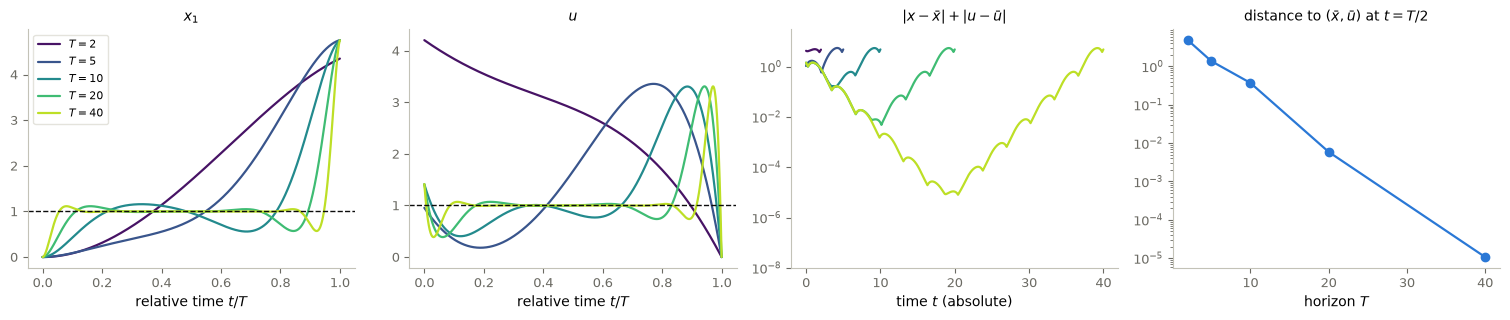

In [3]:
A = np.array([[0.0, 1.0], [-1.0, 0.0]])            # harmonic oscillator
B = np.array([[0.0], [1.0]])
C = np.eye(2)
x_star, x0 = np.array([2.0, 7.0]), np.zeros(2)     # target and initial state
x_bar, u_bar, p_bar = lq_steady_state(A, B, C, x_star)

horizons = [2.0, 5.0, 10.0, 20.0, 40.0]
solutions = {}
for T in horizons:
    t = np.linspace(0, T, 4001)
    x, p, u = lq_optimality_system(A, B, C, x_star, x0, T, t)
    solutions[T] = (t, x, p, u)
    mid = len(t) // 2
    dev = np.linalg.norm(x[mid] - x_bar) + abs(u[mid, 0] - u_bar[0])
    print(f"T = {T:4.0f}: at t = T/2, x = {x[mid].round(5)}, u = {u[mid, 0]: .5f};"
          f"  distance to the steady optimum {dev:.2e}")

fig, axes = P.panels(4, size=(3.8, 3.3))
shades = plt.cm.viridis(np.linspace(0.05, 0.9, len(horizons)))
for (T, (t, x, p, u)), color in zip(solutions.items(), shades):
    axes[0].plot(t / T, x[:, 0], color=color, label=f"$T={T:g}$")
    axes[1].plot(t / T, u[:, 0], color=color)
    axes[2].semilogy(t, np.linalg.norm(x - x_bar, axis=1) + np.abs(u[:, 0] - u_bar[0]), color=color)
for ax, value, name in zip(axes[:2], (x_bar[0], u_bar[0]), ("$x_1$", "$u$")):
    ax.axhline(value, color=P.INK, ls="--", lw=1)
    P.label(ax, "relative time $t/T$", title=name)
P.label(axes[2], "time $t$ (absolute)", title=r"$|x-\bar x|+|u-\bar u|$", ylim=(1e-8, 30))
mids = [np.linalg.norm(solutions[T][1][2000] - x_bar) + abs(solutions[T][3][2000, 0] - u_bar[0])
        for T in horizons]
axes[3].semilogy(horizons, mids, "o-", color=P.BLUE)
P.label(axes[3], "horizon $T$", title=r"distance to $(\bar x,\bar u)$ at $t=T/2$")
plt.show()

For long horizons the optimal state spends most of the time near $(1,0)$, which is **neither the target $(2,7)$ nor the initial state**, and the control stays near $1$ (dashed lines: the steady values of §3). In the third panel all curves leave $t=0$ along the same initial layer, and each rises again only in a terminal layer just before its own $T$. **The layers keep a width of order one, independent of $T$, while the plateau between them grows with $T$.** In relative time (first two panels) the layers therefore shrink and the plateau fills the interval. The distance at the midpoint decreases **exponentially in $T$** (right). This is the **turnpike property**.

## 2. The turnpike: three regions

The name comes from economics. The idea goes back to John von Neumann (1945), and the term to Dorfman, Samuelson and Solow (1958), after an American word for a highway:

> *"There is a fastest route between any two points; and if the origin and destination are close together and far from the turnpike, the best route may not touch the turnpike. But if the origin and destination are far enough apart, it will always pay to get on to the turnpike and cover distance at the best rate of travel, even if this means adding a little mileage at either end."*

For long horizons the optimal trajectory has three regions: an **initial layer**, where it leaves $x^0$ and joins the turnpike; a long **plateau** near the steady optimum; and a **terminal layer**, where it leaves the plateau because nothing is asked at $t=T$ ($p(T)=0$).

**Code and plot.** The three regions for $T=40$, and the distance to the steady optimum against the two exponentials $e^{-\gamma t}$ and $e^{-\gamma(T-t)}$.

eigenvalues of H: [-0.6761-0.97832j -0.6761+0.97832j  0.6761-0.97832j  0.6761+0.97832j];  gamma = 0.67610;  layer width ln(10^3)/gamma = 10.22


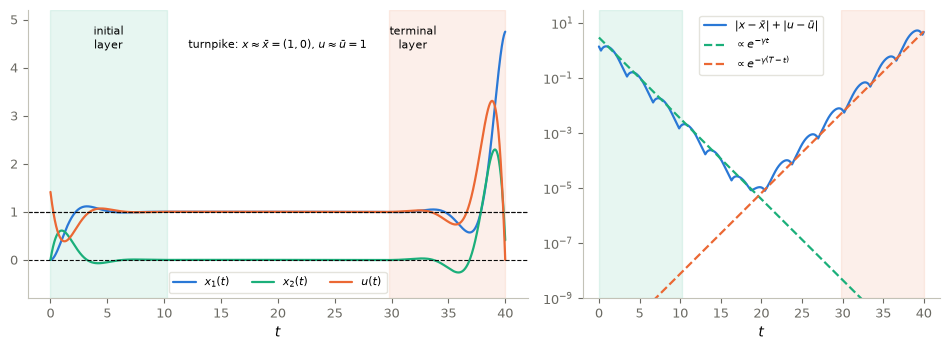

In [4]:
T = 40.0
t, x, p, u = solutions[T]
eig_H = np.linalg.eigvals(hamiltonian_matrix(A, B, C))
gamma = np.min(np.abs(eig_H.real))                 # slowest exponential rate of the deviations
dist = np.linalg.norm(x - x_bar, axis=1) + np.abs(u[:, 0] - u_bar[0])
layer = np.log(1e3) / gamma                        # where the distance drops below 1e-3 of its scale
print(f"eigenvalues of H: {np.round(np.sort_complex(eig_H), 5)};  gamma = {gamma:.5f};"
      f"  layer width ln(10^3)/gamma = {layer:.2f}")

fig, axes = P.panels(2, size=(4.8, 3.6), ratios=[1.4, 1])
for ax in axes:
    ax.axvspan(0, layer, color=P.AQUA, alpha=0.10)
    ax.axvspan(T - layer, T, color=P.ORANGE, alpha=0.10)
axes[0].plot(t, x[:, 0], color=P.BLUE, label="$x_1(t)$")
axes[0].plot(t, x[:, 1], color=P.AQUA, label="$x_2(t)$")
axes[0].plot(t, u[:, 0], color=P.ORANGE, label="$u(t)$")
for value in (x_bar[0], x_bar[1], u_bar[0]):
    axes[0].axhline(value, color=P.INK, ls="--", lw=0.8)
axes[0].text(layer / 2, 4.4, "initial\nlayer", ha="center", fontsize=8)
axes[0].text(T / 2, 4.4, "turnpike: $x\\approx\\bar x=(1,0)$, $u\\approx\\bar u=1$",
             ha="center", fontsize=8)
axes[0].text(T - layer / 2 - 3, 4.4, "terminal\nlayer", ha="center", fontsize=8)
P.label(axes[0], "$t$", ylim=(-0.8, 5.2), legend={"loc": "lower center", "ncol": 3, "fontsize": 8})
axes[1].semilogy(t, dist, color=P.BLUE, label=r"$|x-\bar x|+|u-\bar u|$")
axes[1].semilogy(t, 3 * np.exp(-gamma * t), "--", color=P.AQUA, label=r"$\propto e^{-\gamma t}$")
axes[1].semilogy(t, 5 * np.exp(-gamma * (T - t)), "--", color=P.ORANGE,
                 label=r"$\propto e^{-\gamma (T-t)}$")
P.label(axes[1], "$t$", ylim=(1e-9, 30), legend={"loc": "upper center", "fontsize": 8})
plt.show()

The distance is bounded by a sum of two exponentials, one decaying from $t=0$ and one decaying backward from $t=T$, both at the rate $\gamma\approx0.676$, the smallest $|\operatorname{Re}\lambda|$ over the eigenvalues of the Hamiltonian matrix of §5; the shaded bands have width $\ln(10^3)/\gamma\approx10$. In the middle the distance is about $10^{-5}$, a constant times $e^{-\gamma T/2}$. The oscillations come from the imaginary parts of the eigenvalues, the oscillator's own frequency. The width of the layers does not grow with $T$: a longer horizon only lengthens the plateau. These are the facts the theory must explain.

## 3. The steady problem

The plateau is the solution of the **steady-state control problem**: the same cost, for the steady model,
$$
\min_u\ J_{st}(u)=\tfrac12\big(|u|^2+|C(x-x^*)|^2\big)\qquad\text{subject to}\qquad Ax+Bu=0 .
$$
This is a constrained minimization in $\mathbb R^n$, with a unique minimizer $(\bar x,\bar u)$, characterized by
$$
A\bar x+B\bar u=0,\qquad\bar u=-B^*\bar p,\qquad A^*\bar p+C^*C(\bar x-x^*)=0 .
$$
Here $\bar p$ is the Lagrange multiplier of the constraint.

**By hand for the example.** $A\bar x+B\bar u=0$ means $\bar x_2=0$ and $\bar x_1=\bar u$. It remains to minimize $(x_1-2)^2+(0-7)^2+x_1^2$ over $x_1$, which gives $x_1=1$:
$$
\bar x=(1,0),\qquad\bar u=1,\qquad J_{st}(\bar u)=\tfrac12(1+1+49)=25.5 .
$$
The steady states of the oscillator all have zero velocity, so the target velocity $7$ is unattainable. The steady optimum balances the position error and the control. The multiplier is $\bar p=(7,-1)$, from $A^*\bar p=x^*-\bar x=(1,7)$.

**Code and check.** The steady optimum, and the time-averaged optimal cost against the horizon.

In [5]:
print("steady optimum: x_bar =", x_bar.round(6), " u_bar =", u_bar.round(6),
      " p_bar =", p_bar.round(6))
print("J_st(u_bar) =", 0.5 * (u_bar @ u_bar + (x_bar - x_star) @ (x_bar - x_star)))
for T in horizons:
    t, x, p, u = solutions[T]
    J_T = 0.5 * np.trapezoid(np.sum((x - x_star) ** 2, axis=1) + u[:, 0] ** 2, t)
    print(f"T = {T:4.0f}: J_T / T = {J_T / T:.4f}")

steady optimum: x_bar = [ 1. -0.]  u_bar = [1.]  p_bar = [ 7. -1.]
J_st(u_bar) = 25.500000000000007
T =    2: J_T / T = 17.0291
T =    5: J_T / T = 21.6778
T =   10: J_T / T = 23.6020
T =   20: J_T / T = 24.5519
T =   40: J_T / T = 25.0260


The time-averaged optimal cost $J_T/T$ approaches $J_{st}(\bar u)=25.5$ as $T$ grows. The error decreases like $1/T$, because the two layers contribute a bounded amount. **Averaged in time, the long-horizon problem is the steady problem.** The turnpike property is a much stronger, pointwise statement.

## 4. The optimality system

We derive the optimality conditions with a Lagrangian. The multiplier $p(t)$ enforces the state equation:
$$
\mathscr L(u,x,p)=\frac12\int_0^T\big(|u|^2+|C(x-x^*)|^2\big)dt+\int_0^T\langle p,\,x'-Ax-Bu\rangle\,dt .
$$
For a variation $\delta x$ with $\delta x(0)=0$, integration by parts gives
$$
\langle p(T),\delta x(T)\rangle-\int_0^T\langle p'+A^*p-C^*C(x-x^*),\,\delta x\rangle\,dt=0 ,
$$
and a variation $\delta u$ gives $\int\langle u-B^*p,\delta u\rangle=0$. Replacing $p$ by $-p$, the **optimality system** (OS) reads
$$
\boxed{\;
\begin{aligned}
&x'=Ax+Bu, && x(0)=x^0,\\
&u=-B^*p,\\
&-p'=A^*p+C^*C(x-x^*), && p(T)=0 .
\end{aligned}\;}
$$
The steady OS of §3 is the same system with all time derivatives set to zero.

**Why an initial condition for $x$ and a terminal one for $p$.** The state is prescribed at $t=0$ by the data, so $\delta x(0)=0$. Nothing is prescribed at $t=T$, so $\delta x(T)$ is arbitrary in the variation above, and its coefficient must vanish: $p(T)=0$. This is a *transversality condition*. A terminal cost $\psi(x(T))$ would give $p(T)=\nabla\psi(x(T))$; a terminal constraint $x(T)=x^1$ would leave $p(T)$ free, as for minimal-norm controls. The adjoint inherits its endpoint from what the problem leaves free at $t=T$, which is why it runs backward.

## 5. Forward–backward structure and hyperbolicity

**Two boundary conditions at two different times.** The state starts at $t=0$ and runs forward; the adjoint is prescribed at $t=T$ and runs backward. Eliminating $u$, the deviations $\xi=x-\bar x$ and $\eta=p-\bar p$ solve the *homogeneous* linear system
$$
\begin{pmatrix}\xi\\ \eta\end{pmatrix}'=\mathcal H\begin{pmatrix}\xi\\ \eta\end{pmatrix},\qquad
\mathcal H=\begin{pmatrix}A&-BB^*\\-C^*C&-A^*\end{pmatrix},\qquad\xi(0)=x^0-\bar x,\quad\eta(T)=-\bar p ,
$$
because the steady optimum absorbs the constant terms. $\mathcal H$ is the **Hamiltonian matrix** of the problem.

**A scalar toy model.** Take $x'=u$ and $J_T=\tfrac12\int_0^T(u^2+(x-x^*)^2)$. The steady optimum is $\bar x=x^*$, $\bar u=0$, $\bar p=0$. The OS gives $\xi'=-\eta$ and $\eta'=-\xi$, hence $\xi''=\xi$ with $\xi(0)=x^0-x^*$ and $\xi'(T)=-\eta(T)=0$. The solution is
$$
\xi(t)=(x^0-x^*)\,\frac{\cosh(T-t)}{\cosh T}=(x^0-x^*)\,\frac{e^{-t}+e^{-(2T-t)}}{1+e^{-2T}} .
$$
For large $T$ it is $(x^0-x^*)e^{-t}$ plus an exponentially small correction: an initial layer of width $O(1)$, and a plateau at $\bar x=x^*$. Here the steady multiplier $\bar p=0$ already satisfies $p(T)=0$, so there is no terminal layer. The term $e^{-(2T-t)}$ is the exponentially small trace of the condition at $t=T$. When $\bar p\ne0$, as in §1, the condition $p(T)=0$ creates a terminal layer of the same width. **The exponents $-1$ and $+1$ of the solutions $e^{-t}$, $e^{t}$ of $\xi''=\xi$ are the eigenvalues $\mp1$ of $\mathcal H=\begin{pmatrix}0&-1\\-1&0\end{pmatrix}$.**

**Hyperbolicity.** In general, the turnpike is a direct consequence of the hyperbolicity of the dynamics generated by $\mathcal H$:

- the spectrum of $\mathcal H$ is **symmetric with respect to the imaginary axis**: if $\lambda$ is an eigenvalue, so is $-\lambda$ (Exercise 4);
- under the controllability and observability assumptions of §6, **no eigenvalue lies on the imaginary axis**. Half of them have $\operatorname{Re}\lambda\le-\gamma<0$ and half have $\operatorname{Re}\lambda\ge\gamma>0$.

The solution of the boundary-value problem then splits as $z(t)=z_s(t)+z_u(t)$. The stable part is fixed by the data at $t=0$ and decays like $e^{-\gamma t}$; the unstable part is fixed by the data at $t=T$ and decays backward like $e^{-\gamma(T-t)}$. In the middle both are exponentially small. For the stable part to absorb an *arbitrary* initial state, the stable eigenvectors must project onto the whole state space, i.e. the stable subspace must be a graph over the $x$-variables, and similarly for the unstable subspace and the $p$-variables. Hyperbolicity alone does not guarantee this (Exercise 4); controllability and observability do. The solver `lq_optimality_system` defined at the top uses exactly this splitting: it only evaluates decaying exponentials, which removes the growth by $e^{\gamma T}\approx10^{12}$ (for $T=40$) that a naive shooting method would suffer. This removes one source of ill-conditioning, not all: the conditioning of the eigenvector basis and of the small boundary system still matters, and we have not analysed it in general.

**Code and plot.** Couple the oscillator to a third mode $x_3'=-x_3$ that the control cannot reach:
$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_0=\begin{pmatrix}0\\1\\0\end{pmatrix}.
$$
This is the near-uncontrollable family $B_\varepsilon=(0,1,\varepsilon)^\top$ at $\varepsilon=0$, which is not controllable. Does the turnpike hold for it, with $C=I$? And if that mode were neutral, $x_3'=0$?

oscillator         Kalman rank 2 of 2;  eigenvalues of H: [-0.6761-0.9783j -0.6761+0.9783j  0.6761-0.9783j  0.6761+0.9783j]
family, eps = 0    Kalman rank 2 of 3;  eigenvalues of H: [-1.    +0.j     -0.6761-0.9783j -0.6761+0.9783j  0.6761-0.9783j
  0.6761+0.9783j  1.    +0.j    ]
family, neutral x3 Kalman rank 2 of 3;  eigenvalues of H: [-0.6761-0.9783j -0.6761+0.9783j -0.    +0.j      0.    +0.j
  0.6761-0.9783j  0.6761+0.9783j]


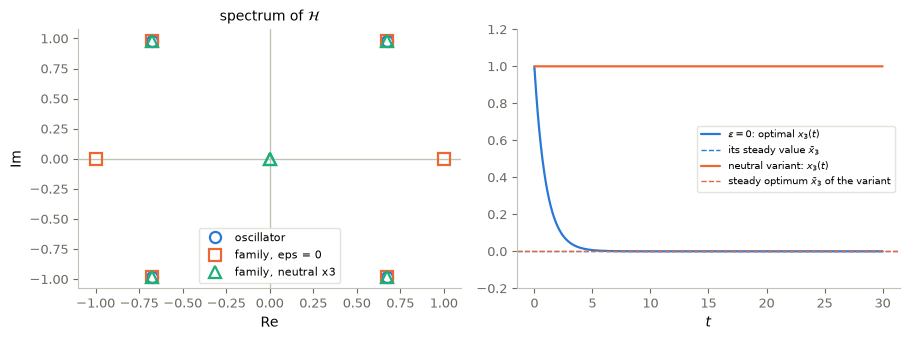

neutral variant: lq_optimality_system refuses it: the Hamiltonian matrix is not hyperbolic (an eigenvalue lies on the imaginary axis)


In [6]:
def kalman(A_, B_):
    cols = [B_]
    for _ in range(A_.shape[0] - 1):
        cols.append(A_ @ cols[-1])
    return np.concatenate(cols, axis=1)

A2 = np.array([[0.0, 1.0, 0.0], [-1.0, 0.0, 0.0], [0.0, 0.0, -1.0]])    # near-uncontrollable family at eps = 0
B2 = np.array([[0.0], [1.0], [0.0]])
A2n = A2.copy(); A2n[2, 2] = 0.0                   # variant with a neutral unreachable mode x3' = 0
C3, x_star3, x03 = np.eye(3), np.array([2.0, 7.0, 0.0]), np.array([0.0, 0.0, 1.0])
cases = {"oscillator": (A, B, C), "family, eps = 0": (A2, B2, C3), "family, neutral x3": (A2n, B2, C3)}
for name, (A_, B_, C_) in cases.items():
    ev = np.linalg.eigvals(hamiltonian_matrix(A_, B_, C_))
    print(f"{name:18s} Kalman rank {np.linalg.matrix_rank(kalman(A_, B_))} of {A_.shape[0]};"
          f"  eigenvalues of H: {np.round(np.sort_complex(ev), 4)}")

T3 = 30.0
t3 = np.linspace(0, T3, 3001)
x3, p3, u3 = lq_optimality_system(A2, B2, C3, x_star3, x03, T3, t3)
x3_bar = lq_steady_state(A2, B2, C3, x_star3)[0]
x3n_frozen = np.full_like(t3, x03[2])              # neutral mode: x3' = 0 whatever u is
x3n_bar = lq_steady_state(A2n, B2, C3, x_star3)[0]

fig, (ax1, ax2) = P.panels(2, size=(4.6, 3.5))
for (name, (A_, B_, C_)), marker in zip(cases.items(), ("o", "s", "^")):
    ev = np.linalg.eigvals(hamiltonian_matrix(A_, B_, C_))
    ax1.plot(ev.real, ev.imag, marker, ms=8, fillstyle="none", mew=1.6, label=name)
P.complex_plane(ax1, title=r"spectrum of $\mathcal{H}$")
ax2.plot(t3, x3[:, 2], color=P.BLUE, label=r"$\varepsilon=0$: optimal $x_3(t)$")
ax2.axhline(x3_bar[2], color=P.BLUE, ls="--", lw=1, label=r"its steady value $\bar x_3$")
ax2.plot(t3, x3n_frozen, color=P.ORANGE, label="neutral variant: $x_3(t)$")
ax2.axhline(x3n_bar[2], color=P.ORANGE, ls="--", lw=1, label=r"steady optimum $\bar x_3$ of the variant")
P.label(ax2, "$t$", ylim=(-0.2, 1.2), legend={"fontsize": 7})
plt.show()
print("neutral variant: lq_optimality_system refuses it:", end=" ")
try:
    lq_optimality_system(A2n, B2, C3, x_star3, x03, T3, t3)
except ValueError as err:
    print(err)

The spectrum of $\mathcal H$ is symmetric with respect to the imaginary axis in all three cases. For the oscillator there are four eigenvalues $\pm0.676\pm0.978i$. The family at $\varepsilon=0$ is **not controllable**, yet its unreachable mode is stable, the extra eigenvalues are $\pm1$, $\mathcal H$ is hyperbolic, and for this problem the turnpike holds: $x_3$ decays by itself to its steady value $0$. In the neutral variant $\mathcal H$ has a double eigenvalue $0$. The mode $x_3$ cannot move at all, so it stays at $1$ for all time. The steady problem, which optimizes over all steady states, puts $\bar x_3=0$. **There is no turnpike**, and the solver refuses the problem because $\mathcal H$ is not hyperbolic.

## 6. The turnpike theorem

> **Theorem 1 (exponential turnpike; [Porretta–Zuazua, 2013](https://doi.org/10.1137/130907239)).**
> *Assumptions:* the pair $(A,B)$ is controllable, $\operatorname{rank}[B,AB,\dots,A^{n-1}B]=n$; and the pair $(A,C)$ is observable, $\operatorname{rank}[C;CA;\dots;CA^{n-1}]=n$. The second condition is void when $C=I$.
>
> *Conclusion:* there are $\gamma>0$ and $K>0$ such that, for $T$ large enough,
> $$\int_{aT}^{bT}\big(|u-\bar u|^2+|x-\bar x|^2\big)\,ds\le K\big(e^{-\gamma aT}+e^{-\gamma(1-b)T}\big)\qquad\text{for every }0\le a\le b\le1 .$$
>
> *Interpretation:* with $\gamma,K$ independent of $T,a,b$, on any interval that stays a fixed fraction away from both ends, the optimal pair is exponentially close to the steady optimum.

**Which turnpike?** Three statements of different strength appear in this notebook.

| Statement | Form | Where, and under which assumptions |
|---|---|---|
| averaged | $\frac1T\int_0^T\big(\lvert u-\bar u\rvert^2+\lvert C(x-\bar x)\rvert^2\big)dt\to0$, and $J_T/T\to J_{st}(\bar u)$ | §3 (numerically) and §7, Step 3; needs boundary terms bounded uniformly in $T$ (Step 4) |
| integral, exponential | Theorem 1 | controllability of $(A,B)$ and observability of $(A,C)$ |
| pointwise, exponential | $\lvert x(t)-\bar x\rvert+\lvert u(t)-\bar u\rvert\le K\big(e^{-\gamma t}+e^{-\gamma(T-t)}\big)$ for all $t\in[0,T]$ | §2; for LQ problems it follows from the stable/unstable splitting of §5 (we do not compute the constants) |

Each statement implies the one above it, up to the value of the rate. The rate in Theorem 1 is *some* $\gamma>0$. In §§1–2, $\gamma$ is the spectral gap $\min\lvert\operatorname{Re}\lambda(\mathcal H)\rvert\approx0.676$, the rate at which the deviations themselves decay; the squared deviations in the theorem's integral then decay at the rate $2\gamma$.

**Two key ingredients.**
1. The cost criterion must penalize **both the state and the control**.
2. **Controllability** (together with observability through $C$), which in Theorem 1 is a *sufficient* condition (see the remark below).

Under the theorem's controllability/observability hypotheses, hyperbolicity of $\mathcal H$ follows (§5).

> **Remark (sufficient, not necessary).** It is sometimes said that controllability is *needed* for the turnpike property. In Theorem 1 it is a *sufficient* hypothesis. The near-uncontrollable family at $\varepsilon=0$ is not controllable, but for this problem the turnpike holds (§5), because its unreachable mode is stable. In LQ theory, the hyperbolicity of $\mathcal H$ together with the graph property of §5 is known to hold under the weaker conditions that the unreachable modes of $(A,B)$ be stable and the unobservable modes of $(A,C)$ be stable. We state this without proof and verify it only on the examples above. The message survives: without some controllability, the turnpike can fail, as the neutral variant shows.

**The first ingredient matters as much.** The minimal-norm control penalizes only the control and imposes a terminal state. Its optimality system has the adjoint isolated, $-\varphi'=A^*\varphi$, with no coupling back from the state ($C=0$). Nothing then ties the trajectory to the steady optimum of a tracking cost. This does not mean that $\mathcal H$ can never be hyperbolic without a state cost: for $A=-1$, $B=1$, $C=0$, $\mathcal H=\begin{pmatrix}-1&-1\\0&1\end{pmatrix}$ has eigenvalues $\pm1$; hyperbolicity then comes from the dynamics $A$ alone. What fails in general is the mechanism of Theorem 1. For the heat equation the minimal-norm controls concentrate near $t=T$ and show no turnpike.

## 7. The proof: dissipativity and the five steps

*Optional.*

Write $\xi=x-\bar x$, $\eta=p-\bar p$, so that $u-\bar u=-B^*\eta$ and $\xi'=A\xi-BB^*\eta$, $-\eta'=A^*\eta+C^*C\xi$.

**Step 1: the dissipativity identity.**
$$
\frac{d}{dt}\langle\xi,\eta\rangle=\langle A\xi-BB^*\eta,\eta\rangle-\langle\xi,A^*\eta+C^*C\xi\rangle=-|B^*\eta|^2-|C\xi|^2 .
$$
The terms $\langle A\xi,\eta\rangle$ and $\langle\xi,A^*\eta\rangle$ cancel.

**Step 2: decay of the correlation.** If $B^*$ and $C$ are coercive, $|B^*\eta|^2+|C\xi|^2\ge\gamma(|\eta|^2+|\xi|^2)\ge2\gamma|\langle\xi,\eta\rangle|$, and the identity gives exponential bounds $-Ke^{-\gamma(T-t)}\le\langle\xi,\eta\rangle(t)\le Ke^{-\gamma t}$, once $\langle\xi,\eta\rangle$ is bounded at $t=0$ and $t=T$. These conditions can be relaxed under controllability and observability (following Cardaliaguet–Lasry–Lions–Porretta).

**Step 3: convergence of averages.** Integrating Step 1 over $(0,T)$, with $\eta(T)=-\bar p$,
$$
\int_0^T\big(|u-\bar u|^2+|C(x-\bar x)|^2\big)dt=\langle\xi(0),\eta(0)\rangle-\langle\xi(T),\eta(T)\rangle=\langle x^0-\bar x,\,p(0)-\bar p\rangle+\langle x(T)-\bar x,\,\bar p\rangle .
$$
If the right-hand side is bounded independently of $T$ (Step 4), then $\frac1T\int_0^T(\dots)\le C/T\to0$, and the averaged minima converge to the steady minimum. This is the computation printed in §3.

**Step 4: bounds on the extremal values.** The observability inequality for $(A^*,B^*)$ bounds $|p(0)-\bar p|$ by the observed quantities $\int|B^*\eta|^2$ and $\int|C\xi|^2$. The observability of $(A,C)$ bounds $|x(T)-\bar x|$ in the same way. Inserted into Step 3, this gives bounds independent of $T$.

**Step 5: the exponential estimate.** Integrating Step 1 over $(aT,bT)$,
$$
\int_{aT}^{bT}\big(|u-\bar u|^2+|C(x-\bar x)|^2\big)dt=\langle\xi,\eta\rangle(aT)-\langle\xi,\eta\rangle(bT),
$$
and Step 2 bounds the right-hand side by $K(e^{-\gamma aT}+e^{-\gamma(1-b)T})$. Observability of $(A,C)$ then turns the bound on $C\xi$ into a bound on $\xi$.

**Code and check.** The identity of Step 3, verified on the solution of §1 for $T=20$.

In [7]:
T = 20.0
t, x, p, u = solutions[T]
lhs = np.trapezoid(np.sum((u - u_bar) ** 2, axis=1) + np.sum((x - x_bar) ** 2, axis=1), t)
rhs = (x0 - x_bar) @ (p[0] - p_bar) + (x[-1] - x_bar) @ p_bar
print(f"int (|u - u_bar|^2 + |x - x_bar|^2) = {lhs:.8f};  boundary terms = {rhs:.8f}"
      f"  (trapezoidal rule, step {t[1] - t[0]:.3f})")

int (|u - u_bar|^2 + |x - x_bar|^2) = 27.74714212;  boundary terms = 27.74711307  (trapezoidal rule, step 0.005)


## 8. PDEs: balanced controls for the heat equation

In this section $x$ is the spatial variable, $y$ the state and $u$ the control. The minimal-norm null control of the heat equation has no turnpike. Consider instead a control that **balances the state and the control**:
$$
\min_u\ \frac12\int_0^T\!\!\int_\Omega|y|^2\,dx\,dt+\frac12\int_0^T\!\!\int_\omega|u|^2\,dx\,dt,\qquad y_t-\Delta y=u\,1_\omega .
$$
Its optimality system couples the state and the adjoint in both directions: $y_t-\Delta y=-\varphi1_\omega$ and $-\varphi_t-\Delta\varphi=y$. The source term $y$ in the adjoint equation is the novelty.

**A forward–backward parabolic system.** For simplicity take $\omega=\Omega$. Then $y_t-\Delta y=-\varphi$ and $\varphi_t+\Delta\varphi=-y$. On the eigenfunction of $-\Delta$ with eigenvalue $\lambda_j$, the two coefficients solve
$$
\begin{pmatrix}y_j\\ \varphi_j\end{pmatrix}'=\begin{pmatrix}-\lambda_j&-1\\-1&\lambda_j\end{pmatrix}\begin{pmatrix}y_j\\ \varphi_j\end{pmatrix},
$$
with characteristic values $\mu_j^\pm=\pm\sqrt{1+\lambda_j^2}$. The system is a superposition of growing and decaying real exponentials, all with rates at least $\sqrt{1+\lambda_1^2}$. This is the hyperbolic structure of §5, mode by mode: the turnpike behaviour is automatically ensured once the optimality criterion weights both state and control, provided $T\gg1$.

**Waves.** The same holds for the wave equation: the control and the controlled trajectories are close to the steady ones during most of the interval when $T\gg1$ ([Gugat–Trélat–Zuazua, 2016](https://doi.org/10.1016/j.sysconle.2016.02.001)). In infinite dimension the controllability ingredient becomes a condition on $\omega$. For the heat equation on a bounded domain, null controllability holds for every nonempty open $\omega\subset\Omega$ (Fursikov–Imanuvilov, Lebeau–Robbiano; cited without proof), and the turnpike holds with any such control support, within the extension of the linear theory to semigroups ([Porretta–Zuazua, 2013](https://doi.org/10.1137/130907239)), which we do not prove. For the wave equation $\omega$ must satisfy the Geometric Control Condition; when it fails, only weaker turnpike properties with slower rates are known.

## 9. Nonlinear turnpike and open problems

*Optional.*

**Nonlinear finite-dimensional systems ([Trélat–Zuazua, 2015](https://doi.org/10.1016/j.jde.2014.09.005)).** The strategy of proof is local: write the optimality system, linearize it around the steady optimum, check the hyperbolic structure of the linearized system, and return to the nonlinear problem by perturbation theory. A worked example is $x_1'=x_2$, $x_2'=1-x_1+x_2^3+u$, with cost $\tfrac12\int((x_1-1)^2+(x_2-1)^2+(u-2)^2)$, whose static optimum is $\bar x=(2,0)$, $\bar u=1$ (Exercise 5).

**Local versus global turnpike.** For $x'=-3x+3x^3+u$ with cost $\int((x-1)^2+(u-1)^2)$, the static problem has a global minimizer $\bar x\approx0.78$ ($\bar u\approx0.91$) and a local one $\bar x_{\rm loc}\approx-1.10$ ($\bar u\approx0.73$). Which of the two a long-horizon optimal trajectory approaches depends on the initial data, the accessibility of each optimum, the cost of the transition and the horizon; the local analysis does not decide it (Exercise 6).

**Semilinear heat (Porretta–Zuazua).** For $y_t-\Delta y+y^3=u1_\omega$ with a tracking cost, the linearized optimality system around the steady optimum $(\bar y,\bar\varphi)$ reads $z_t-\Delta z+3\bar y^2z=-\psi1_\omega$, $-\psi_t-\Delta\psi+3\bar y^2\psi=\rho z$ with $\rho(x)=1-6\bar y\bar\varphi$. With the adjoint convention of this notebook ($u=-\psi1_\omega$), this is the OS of the LQ problem $\min\frac12\int\!\!\int_\Omega\rho\,|z|^2+\frac12\int\!\!\int_\omega|u|^2$: $\rho$ is a weight on the **state**, with unit weight on the control. The turnpike holds as soon as $\rho\ge\delta>0$, a positive state cost as in the first ingredient of §6, which is guaranteed when the target is small enough.

**Open problems.** The turnpike for nonlinear PDEs without smallness conditions; optimal control of time-dependent diffusivity coefficients, $y_t-\operatorname{div}(\sigma(x,t)\nabla y)=0$; combining the local analysis with dissipativity techniques (Grüne et al.); periodic turnpike; turnpike for shape design; and the use of turnpike to solve constrained controllability problems in large time. The literature goes back to discrete-time economic models (McKenzie, 1963) and includes biology, locomotion and model predictive control.

## 10. Control ↔ ML: long horizons and deep networks

A residual network with $K$ layers can be read as an Euler discretization, with step $h$, of a controlled ODE on $[0,Kh]$. Adding layers can mean two different things: refining the step on a *fixed* horizon, which approximates one continuous-time problem better; or keeping $h$ fixed so that the horizon $Kh$ grows, which is a long-horizon problem in the sense of this notebook. Turnpike theory speaks to the second reading. Training such a network with a running cost on the parameters and the features is then a long-horizon optimal control problem, and turnpike theory suggests that such long controlled evolutions may develop an interior regime that is largely independent of the transients at the two ends. This is a hypothesis to be examined, not a theorem about neural networks: the results of this notebook concern linear-quadratic problems with controllability, and deep networks do not generically satisfy a turnpike theorem. See [Geshkovski–Zuazua, *Acta Numerica* 2022](https://doi.org/10.1017/S0962492922000046) for this line of work.

## 11. Common misconceptions

**"Over a long horizon, the optimal state goes to the target."** It goes to the *steady optimum* $\bar x$, which balances the target against the control, and which may differ from $x^*$ (here $(1,0)$ versus $(2,7)$).

**"The turnpike is a property of the system."** It depends on the cost. Minimal-norm heat controls show no turnpike; in Theorem 1, costs that penalize state and control do, under its hypotheses.

**"Controllability is necessary for the turnpike."** It is a sufficient hypothesis. In the examples of §5, a stable unreachable mode is harmless (the near-uncontrollable family at $\varepsilon=0$) and a neutral one destroys the turnpike.

**"Long horizons make the problem harder to solve."** Naive shooting becomes ill-conditioned like $e^{\gamma T}$; a solver that uses the stable/unstable splitting avoids that exponential growth (other sources of ill-conditioning remain possible). Hyperbolicity is both the explanation and the remedy for this particular difficulty.

**"The layers widen as $T$ grows."** Their width is set by $1/\gamma$, independently of $T$ (§2).

## 12. Key takeaways

1. LQ problem: $\min\tfrac12\int_0^T(|u|^2+|C(x-x^*)|^2)$ subject to $x'=Ax+Bu$. Steady problem: the same cost subject to $Ax+Bu=0$.
2. Optimality system: $u=-B^*p$, $-p'=A^*p+C^*C(x-x^*)$, $p(T)=0$. It is a forward–backward system.
3. The deviations from the steady optimum solve $z'=\mathcal Hz$ with the Hamiltonian matrix $\mathcal H=\begin{pmatrix}A&-BB^*\\-C^*C&-A^*\end{pmatrix}$, whose spectrum is symmetric about the imaginary axis.
4. Hyperbolicity of $\mathcal H$, with the graph property of §5, gives an initial layer $\sim e^{-\gamma t}$, a plateau and a terminal layer $\sim e^{-\gamma(T-t)}$: the turnpike.
5. Theorem: controllability of $(A,B)$ and observability of $(A,C)$ give the exponential turnpike. Its proof rests on the dissipativity identity $\frac{d}{dt}\langle\xi,\eta\rangle=-|B^*\eta|^2-|C\xi|^2$.
6. Two ingredients: a cost on state and control, and controllability (sufficient, not necessary). Minimal-norm heat controls lack the first; a neutral unreachable mode violates the second.
7. Balanced heat controls have characteristic values $\pm\sqrt{1+\lambda_j^2}$ and a turnpike.

## 13. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Predict the plateau. ★** For the example of §1 with the new target $x^*=(3,-5)$, predict the turnpike $(\bar x,\bar u)$ *before* computing, and then check it with `lq_steady_state`. Why does the target velocity not matter?
2. **Steady optimum by hand. ★★** For the harmonic oscillator with $C=I$ and a general target $x^*=(a,b)$, compute $\bar x$, $\bar u$ and $\bar p$ from the steady optimality system $A\bar x+B\bar u=0$, $\bar u=-B^*\bar p$, $A^*\bar p+\bar x-x^*=0$. Check that you recover §3 for $(a,b)=(2,7)$.
3. **The dissipativity identity. ★★** (a) Derive $\frac{d}{dt}\langle x-\bar x,p-\bar p\rangle=-|B^*(p-\bar p)|^2-|C(x-\bar x)|^2$ from the time-dependent and steady optimality systems. (b) Integrate it to get the identity of Step 3 (§7), and use it to show $J_T(u)/T\to J_{st}(\bar u)$ *provided* the boundary terms stay bounded. *Hint:* write $J_T$ in terms of $u-\bar u$ and $x-\bar x$, and use the steady optimality conditions to write the cross terms as an exact derivative.
4. **Spectral symmetry. ★★** Let $J=\begin{pmatrix}0&I\\-I&0\end{pmatrix}$. (a) Show that $J\mathcal H$ is symmetric. (b) Deduce that $\mathcal H^\top=J\mathcal HJ$ and that $\mathcal H$ and $-\mathcal H$ have the same eigenvalues. Since $\mathcal H$ is real, conclude that its spectrum is symmetric with respect to both axes. (c) For the scalar model $A=a$, $B=b$, $C=c$, compute the eigenvalues $\pm\sqrt{a^2+b^2c^2}$, and say when they are on the imaginary axis.
5. **A nonlinear turnpike. ★★★** For $x_1'=x_2$, $x_2'=1-x_1+x_2^3+u$, $x(0)=(1,1)$, and $\min\tfrac12\int_0^T((x_1-1)^2+(x_2-1)^2+(u-2)^2)$: (a) verify the static optimum $\bar x=(2,0)$, $\bar u=1$. (b) Write the optimality system. (c) For $T=5,10,20$, compute *stationary candidates* of the optimality system numerically — for instance by Newton or gradient descent on the unknown $p(0)$, rolling the system out with an RK4 integrator and differentiating through the rollout with `torch` — and observe whether the candidates approach the static optimum in the middle of the interval. (d) Why does a converged run not certify that a candidate is a global minimizer of the cost?
6. **Local versus global. ★★★** For $x'=-3x+3x^3+u$ and the cost $\int_0^T((x-1)^2+(u-1)^2)$: (a) reduce the static problem to the minimization of $g(x)=(x-1)^2+(3x-3x^3-1)^2$ and find its two local minimizers, comparing with the values $\bar x\approx0.78$, $\bar u\approx0.91$ and $\bar x_{\rm loc}\approx-1.10$, $\bar u\approx0.73$. (b) Which one is the global minimizer of the static problem? (c) *Discussion:* for a long horizon and a start near $-1.1$, which factors decide whether the optimal trajectory stays near the local steady optimum or moves to the global one? Discuss the accessibility of the global optimum under the drift, the cost of the transition, the length of the horizon, and the fact that the turnpike analysis is local. Can the question be settled without solving the time-dependent problem?

In [8]:
# TODO: student exercise (Exercise 5)
# Write the right-hand side of the nonlinear optimality system z = (x1, x2, p1, p2) with the
# boundary conditions x(0) = (1, 1), p(T) = 0, and solve it by shooting on p(0) for T = 5, 10, 20.

def nonlinear_os(t, z):
    ...  # your code here
    return None

## Where are we going?

This closes Part II. Its tools are minimization, gradient flows and their discretization, adjoints and duality for PDEs, and the long-horizon structure of optimal control. Part III turns to **learning from data**, where the same machinery returns under new names: the cost becomes a loss, the control becomes the parameters of a model, and gradient descent becomes training ([notebook 09](09_machine_learning_foundations_generalization.ipynb)). In Part IV, deep residual networks are read as controlled dynamical systems over long horizons, and the turnpike of this notebook becomes a question about deep architectures.

## References

1. A. Porretta, E. Zuazua, [*Long time versus steady state optimal control*](https://doi.org/10.1137/130907239), SIAM Journal on Control and Optimization **51** (2013), 4242–4273.
2. E. Trélat, E. Zuazua, [*The turnpike property in finite-dimensional nonlinear optimal control*](https://doi.org/10.1016/j.jde.2014.09.005), Journal of Differential Equations **258** (2015), 81–114.
3. M. Gugat, E. Trélat, E. Zuazua, [*Optimal Neumann control for the 1D wave equation: finite horizon, infinite horizon, boundary tracking terms and the turnpike property*](https://doi.org/10.1016/j.sysconle.2016.02.001), Systems & Control Letters **90** (2016), 61–70.
4. B. Geshkovski, E. Zuazua, [*Turnpike in optimal control of PDEs, ResNets, and beyond*](https://doi.org/10.1017/S0962492922000046), Acta Numerica **31** (2022), 135–263.
5. R. Dorfman, P. A. Samuelson, R. M. Solow, [*Linear Programming and Economic Analysis*](https://archive.org/details/linearprogrammin0000dorf), McGraw-Hill, 1958.
6. L. W. McKenzie, [*Turnpike theorems for a generalized Leontief model*](https://doi.org/10.2307/1909346), Econometrica **31** (1963), 165–180.